<!-- DATA PROVIDER INSTRUCTIONS

1. Provide the name of your dataset, replacing the bracketed placeholder text.
2. Update the Registry of Open Data landing page URL, by replacing the bracketed placeholder text. The [REGISTRY_YAML_NAME] will correspond to the name of the YAML document in your pull request to the Registry of Open Data on Github, minus the .yaml file extension.
3. Remove these comment blocks when you have completed each section.

DATA PROVIDER INSTRUCTIONS -->

# Get to Know a Dataset: Bureau of meteorology Atmospheric Regional Reanalysis for Australia - Version 1 (BARRA)

This notebook serves as a guided tour of the Bureau of meteorology Atmospheric Regional Reanalysis for Australia - Version 1 (https://registry.opendata.aws/australian-bureau-of-meteorology-barra-1) dataset. More usage examples, tutorials, and documentation for this dataset and others can be found at the [Registry of Open Data on AWS](https://registry.opendata.aws/).

<!-- DATA PROVIDER INSTRUCTIONS

The goal of this section is to orient users to the structure of your dataset. 

1. How are key prefixes and objects organized in your S3 bucket?
2. What kinds of filetypes are represented in your dataset?
3. Explain with text what users are expected to encounter, and then demonstrate with code the organizational framework you applied when creating your dataset.
4. The responses to each question section are meant to be expanded or replaced as dictated by your dataset

DATA PROVIDER INSTRUCTIONS -->

### Q: How have you organized your dataset? Help us understand the key prefix structure of your S3 bucket.
At the top level of our S3 bucket, we have 3 top level prefixes, BARRA, BARRA 2 (superseding BARRA), and BARPA.
The BARRA directory contains:

```
|-- BARRA
        |-- BARRA_R/v1/
        |-- BARRA_AD/v1/
        |-- BARRA_PH/v1/
        |-- BARRA_SY/v1/
        |-- BARRA_TA/v1/
```

#### BARRA-R Regional
BARRA-R is a national moderate-resolution (12 km) regional atmospheric reanalysis over Australia, and the surrounding region including parts of southeast Asia, New Zealand, and south to the ice edge of the Antarctic continent. The data set includes hourly forecasts and 6-hourly analyses for temperature, moisture, wind and flux variables at sub-surface, surface, and pressure and model levels. There are 37 pressure levels from 1000 to 0.1 hPa, and subsetted 38 model levels. The data set covers from the time period from January 1990 to February 2019.

Directory: *BARRA/BARRA_R/v1/forecast* (hourly forecasts) & *BARRA/BARRA_R/v1/analysis* (6-hourly analyses)

#### BARRA-AD Convective-Scale
BARRA-AD is a kilometre-scale (1.5 km) downscaled reanalysis over south Australia centred at Adelaide (131 to 142 deg East longitude, -39.5 to -29.5 deg South Latitude). The data set includes hourly data for temperature, moisture, wind and flux variables at sub-surface, surface, and pressure levels. There are 21 pressure levels from 1000 to 10 hPa. The data set covers from the time period from January 1990 to February 2019.

Directory: *BARRA/BARRA_AD/v1/forecast* (hourly forecasts)

#### BARRA-PH Convective-Scale
As with BARRA-AD but over south-western Western Australia at Perth (112 to 124 deg East longitude, -37 to -27 deg South Latitude).

Directory: *BARRA/BARRA_PH/v1/forecast* (hourly forecasts)

#### BARRA-SY Convective-Scale
As with BARRA-AD but over eastern New South Wales centred Sydney (147 to 155 deg East longitude, -38 to -28 deg South Latitude).

Directory: *BARRA/BARRA_SY/v1/forecast* (hourly forecasts)

#### BARRA-TA Convective-Scale
As with BARRA-AD but over Tasmania (142.5 to 150.5 deg East longitude, -46 to -39.15 deg South Latitude).

Directory: *BARRA/BARRA_TA/v1/forecast* (hourly forecasts)

### Documentation
Full documentation for this dataset can be found at: https://thredds.nci.org.au/thredds/fileServer/cj37/BARRA/FAQ_BARRA_August_2020.pdf (replace reference to ```/g/data/ma05``` to S3 top-level prefix).

<!-- DATA PROVIDER INSTRUCTIONS
This section is meant to orient users of your dataset to the formats present in your dataset, particularly if your dataset includes formats that may be unfamiliar to a general data scientist audience. This section should include:

1. Explanation of data format(s) (very common formats can be very briefly described, while less common
   or domain specific formats should include more explanation as well as links to official documentation)
2. Explanation of why the data format was chosen for your dataset
3. Recommendations around software and tooling to work with this data format
4. Explanation of any dataset-specific aspects to your usage of the format
5. Description of AWS services that may be useful to users working with your data
DATA PROVIDER INSTRUCTIONS -->

### Q: What data formats are present in your dataset? What kinds of data are stored using these formats? Can you give any advice for how you work with these data formats?

The datasets are provided as extensive sets of netCDF4 files. 
  
The datasets are organised as one data file per parameter (and per vertical pressure level, if relevant), per 6-hour block.

Working with netCDF (.nc) files involves handling multidimensional scientific data. netCDF files are self-describing, holding variables, dimensions, and metadata (CF conventions), making them standard for climate and atmospheric data. Use libraries such as xarray and netCDF4. xarray  provides a high-level, pandas-like interface for multi-dimensional data, while the netCDF4 library offers a lower-level interface, offering full control over file structure, compression, and other advanced features. Data is typically accessed as NumPy arrays.

See https://docs.xarray.dev/en/stable/user-guide/io.html for loading NetCDF into xarray.

### Q: Do you have example (or several!) that either illustrates something informative about your dataset, or that you think might excite someone to dig in further.

Regional atmospheric reanalyses like BARRA offer a remarkably rich view of the atmosphere because they blend global observational networks with high resolution numerical modelling to reconstruct atmospheric conditions consistently through time. Unlike coarse global products, regional reanalyses resolve fine‑scale features from boundary‑layer structure and local wind systems to mesoscale convection and upper‑tropospheric dynamics—capturing how processes interact vertically and horizontally across the domain. 

The multi‑decadal coverage of BARRA from January 1990 to February 2019, provides a physically coherent picture of temperature, moisture, winds, and pressure throughout the atmospheric column, enabling detailed analysis of weather systems, climate variability, and extremes. This richness makes regional reanalysis data an indispensable foundation for research, impact assessment, and applications that depend on understanding the full three‑dimensional behaviour of the atmosphere and land surface.

#### Example 1: October 2014 Thunderstorms
This were significant weather events during 13-15 October 2014. 
On 13th, there was a squall line moved through Sydney producing hail and lightning. On 14-15th, a storm system brought severe thunderstorms associated with a surface trough and East Coast Low. 

In [1]:
# Load required Python modules 
import os, sys
import glob
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd
import cartopy.crs as ccrs
from matplotlib.colors import ListedColormap, BoundaryNorm

In [2]:
#
# OVERLY SIMPLIFIED METHOD FOR OPENING DATA FILES -- THESE SHOULD BE REPLACED METHODS FOR QUERYING AWS OPEN DATA
#
def open_barra_dataset(model_id, output, variable, yearmonth):
    """
    Load a BARRA reanalysis dataset for a specified model, variable,
    frequency, and year–month period.

    This function constructs the expected file path for a BARRA2 NetCDF file, 
    then opens the dataset with xarray. It assumes the
    file exists and follows the standard BARRA2 directory and naming
    conventions.

    Parameters
    ----------
    model_id : str
        Identifier for the model configuration (e.g., "BARRA-R", "BARRA-SY").
    output : str
        Output type (e.g., "spec", "prs").
    variable : str
        Variable name (e.g., "temp_scrn") used in both the directory and filename.
    yearmonth : str
        Year–month string in YYYYMM format specifying the target file period.

    Returns
    -------
    xarray.Dataset
        The opened BARRA2 dataset corresponding to the requested parameters.

    Notes
    -----
    This function does not perform error checking. If the constructed file path
    does not exist or the file is unreadable, `xr.open_dataset` will raise an
    exception.
    """
    year = yearmonth[:4]
    month = yearmonth[4:]
    model_id = model_id.replace("-", "_")
    root_datapath = f'/g/data/cj37/BARRA/{model_id}/v1/forecast'
    
    file_path = os.path.join(root_datapath, 
                             output, 
                             variable, 
                             year,
                             month,
                             f"{variable}-*.nc")
    
    files = glob.glob(file_path)
    
    ds = xr.open_mfdataset(files)
    
    return ds

In [3]:
# Define which sub-collection of BARRA
yearmonth = '201410'

# From the BARRA-R 12 km reanalysis over CORDEX-Australasia domain
da_list = {}
model_id = 'BARRA-R'
da_list[model_id] = {}
# Hourly mean-sea level pressure
da_list[model_id]['mslp'] = open_barra_dataset(model_id, 'spec', 'mslp', yearmonth)['mslp']
# Hourly zonal wind on pressure levels
da_list[model_id]['wnd_ucmp'] = open_barra_dataset(model_id, 'prs', 'wnd_ucmp', yearmonth)['wnd_ucmp']
# Hourly meridional wind on pressure levels
da_list[model_id]['wnd_vcmp'] = open_barra_dataset(model_id, 'prs', 'wnd_vcmp', yearmonth)['wnd_vcmp']

# From the BARRA-SY 1.5 km downscaled reanalysis over New South Wales domain
model_id = 'BARRA-SY'
da_list[model_id] = {}
# Hourly precipitation
da_list[model_id]['accum_ls_prcp'] = open_barra_dataset(model_id, 'spec', 'accum_ls_prcp', yearmonth)['accum_ls_prcp']
# Hourly maximum wind gust
da_list[model_id]['max_wndgust10m'] = open_barra_dataset(model_id, 'spec', 'max_wndgust10m', yearmonth)['max_wndgust10m']
# Hourly 10 m zonal wind
da_list[model_id]['uwnd10m'] = open_barra_dataset(model_id, 'spec', 'uwnd10m', yearmonth)['uwnd10m']
# Hourly 10 m meridional wind
da_list[model_id]['vwnd10m'] = open_barra_dataset(model_id, 'spec', 'vwnd10m', yearmonth)['vwnd10m']

In [4]:
# Print their standard name and units
for model_id in da_list:
    for variable in da_list[model_id]:
        print(f"From {model_id}: {variable}: {da_list[model_id][variable].standard_name}, {da_list[model_id][variable].units}")

From BARRA-R: mslp: air_pressure_at_sea_level, Pa
From BARRA-R: wnd_ucmp: x_wind, m s-1
From BARRA-R: wnd_vcmp: y_wind, m s-1
From BARRA-SY: accum_ls_prcp: stratiform_rainfall_amount, kg m-2
From BARRA-SY: max_wndgust10m: wind_speed_of_gust, m s-1
From BARRA-SY: uwnd10m: x_wind, m s-1
From BARRA-SY: vwnd10m: y_wind, m s-1


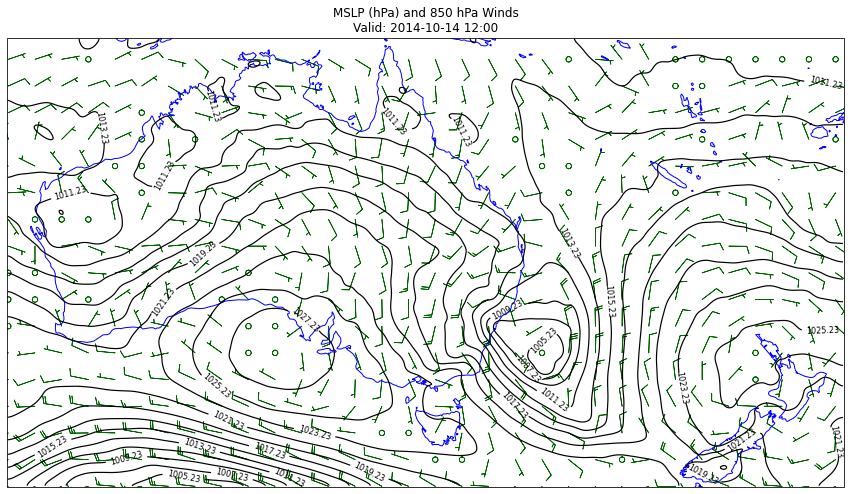

In [5]:
# Define a larger Australian domain to look at broader synoptic environment
aus_latrange = slice(-47, -10)
aus_lonrange = slice(111, 180)

# Use the BARRA-R reanalysis
model_id = 'BARRA-R'
valid_time = '2014-10-14 12:00'

# Create the figure
fig = plt.figure(figsize=(15, 12))
ax = plt.subplot(projection=ccrs.PlateCarree())
from scipy.ndimage import gaussian_filter

# Plot MSLP
da_psl_sel = da_list[model_id]['mslp'].sel(latitude=aus_latrange, longitude=aus_lonrange).sel(time=valid_time, method='nearest')
da_psl_sel = da_psl_sel / 100 # Convert Pa to hPa
psl_smooth = gaussian_filter(da_psl_sel, sigma=3)
levels = np.arange(psl_smooth.min(), psl_smooth.max(), 2)
cs = ax.contour(da_psl_sel['longitude'], da_psl_sel['latitude'], psl_smooth, levels=levels, colors='black', linewidths=1.2)
ax.clabel(cs, inline=True, fontsize=8)

# Plot wind field
pressure_level = 850
da_u_sel = da_list[model_id]['wnd_ucmp'].sel(latitude=aus_latrange, longitude=aus_lonrange).sel(time=valid_time, pressure=pressure_level, method='nearest')
da_v_sel = da_list[model_id]['wnd_vcmp'].sel(latitude=aus_latrange, longitude=aus_lonrange).sel(time=valid_time, pressure=pressure_level, method='nearest')
# Subsample to avoid clutter
step = 20
lon_sub = da_u_sel['longitude'][::step]
lat_sub = da_u_sel['latitude'][::step]
u_sub = da_u_sel.values[::step, ::step]
v_sub = da_v_sel.values[::step, ::step]
ax.barbs(lon_sub, lat_sub, 
         u_sub, v_sub,
         length=6, linewidth=0.8,
         color='darkgreen'
        )

# Add coastlines
ax.coastlines(color='blue')
# Set the plot domain
ax.set_xlim(aus_lonrange.start, aus_lonrange.stop)
ax.set_ylim(aus_latrange.start, aus_latrange.stop)
# Add title to the figure
ax.set_title(f"MSLP (hPa) and {pressure_level} hPa Winds\nValid: {valid_time}");

This map shows the large-scale circulation patterns showing the associated surface trough and East Coast Low.

In [6]:
# Plot precipitation at different times during the event
valid_times = ['2014-10-13 06:00','2014-10-13 07:00', '2014-10-13 08:00', \    # for 13th
               '2014-10-14 06:00', '2014-10-14 08:00', '2014-10-14 10:00']     # for 14th

# Define Sydney domain
latrange = slice(-38, -28)
lonrange = slice(147, 155)

# figure label
label = 'Hourly precipitation (mm/h)'

# Define discrete precipitation bins (mm/hr)
pr_bounds = [0, 0.2, 1, 3, 10, 20, 40]
# Custom discrete colors (light → heavy)
pr_colors = [
    "#f2f2f2",  # 0–0.2 drizzle
    "#9ecae1",  # 0.2–1 light blue
    "#3182bd",  # 1–3 blue
    "#31a354",  # 3–10 green
    "#fed976",  # 10–40 yellow
    "#b10026"   # 40–80 dark red (extreme)
]
cmap = ListedColormap(pr_colors)
norm = BoundaryNorm(pr_bounds, ncolors=cmap.N)

# Create figure
fig, axes = plt.subplots(2, 3, figsize=(12, 8), subplot_kw={"projection": ccrs.PlateCarree()})

for ax, valid_time in zip(axes.flat, valid_times):
    # Subset the data over the region and for a specific time
    da = da_list['BARRA-SY']['accum_ls_prcp'].sel(latitude=latrange, longitude=lonrange).sel(time=valid_time)
    # Plot
    da.plot(
        ax=ax,
        cmap=cmap, 
        norm=norm,
        extend='max',
        cbar_kwargs={'shrink': 0.5, 'label':''}
    )
    
    # Add coastlines
    ax.coastlines()
    # Set the plot domain
    ax.set_xlim(lonrange.start, lonrange.stop)
    ax.set_ylim(latrange.start, latrange.stop)
    # Add title to each subfigure
    ax.set_title(f"{label}\nValid: {valid_time}")

SyntaxError: unexpected character after line continuation character (3893491030.py, line 2)

The first row of figures show shows the evolution of the squall lines on 13th, and the second row shows the severe thunderstorms on 14th.

In [ ]:
# Plot hourly maximum wind gust at a given time
label = 'Hourly max wind gust (m s-1)'
valid_time = '2014-10-14 12:00'

# Define discrete wind‑gust categories (m/s)
gust_bounds = [0, 10, 15, 20, 25, 30, 35, 40]
# Matching colours (one per interval)
gust_colors = [
    "#d4f0ff",  # 0–10
    "#92c5de",  # 10–15
    "#4393c3",  # 15–20
    "#2166ac",  # 20–25
    "#f4a582",  # 25–30
    "#d6604d",  # 30–35
    "#b2182b"   # 35–40+
]
cmap = ListedColormap(gust_colors)
norm = BoundaryNorm(gust_bounds, ncolors=cmap.N)

fig, ax = plt.subplots(1, 1, figsize=(15, 10), subplot_kw={"projection": ccrs.PlateCarree()})

# Subset the data over the domain and for given time
da = da_list['BARRA-SY']['max_wndgust10m'].sel(latitude=latrange, longitude=lonrange).sel(time=valid_time)
# Plot
da.plot(ax=ax,
        cmap=cmap, 
        norm=norm,
        cbar_kwargs={
                'shrink': 0.8, 
                'label':''
            }
       )

# Plot the 10 m wind barbs on top
da_u_sel = da_list['BARRA-SY']['uwnd10m'].sel(latitude=aus_latrange, longitude=aus_lonrange).sel(time=valid_time, method='nearest')
da_v_sel = da_list['BARRA-SY']['vwnd10m'].sel(latitude=aus_latrange, longitude=aus_lonrange).sel(time=valid_time, method='nearest')
# Subsample to avoid clutter
step = 30
lon_sub = da_u_sel['longitude'][::step]
lat_sub = da_u_sel['latitude'][::step]
u_sub = da_u_sel.values[::step, ::step]
v_sub = da_v_sel.values[::step, ::step]
ax.barbs(lon_sub, lat_sub, 
         u_sub, v_sub,
         length=6, linewidth=0.8,
         color='m'
        )

# Add coastlines
ax.coastlines(color='black')
# Set the plot domain
ax.set_xlim(lonrange.start, lonrange.stop)
ax.set_ylim(latrange.start, latrange.stop)
# Add title to the figure
ax.set_title(f"{label}: {valid_time}");

The storm system brought strong destructive winds with maximum gusts reaching 115 km/h (32 m s-1) recorded at Kurnell weather station ([Bureau of Meteorology Monthly Climate Summary for Sydney](https://www.bom.gov.au/climate/current/month/nsw/archive/201410.sydney.shtml)).

#### Example 2: South Australian Black Storm, September 2016
South Australia experienced a severe wind storm that caused wind-spread damage at the end of September 2016. Severe thunderstorms, high winds, tornadoes, large hail,
and intense rainfall were all observed. The event occurred during the passage of a deep cut-off low through the Great Australian Bight, when an associated cold front moved
across the state. 

In [ ]:
# Define which sub-collection of BARRA
yearmonth = '201609'

# From the BARRA-R 12 km reanalysis over CORDEX-Australasia domain
da_list = {}
model_id = 'BARRA-R'
da_list[model_id] = {}
# Hourly maximum wind gust
da_list[model_id]['max_wndgust10m'] = open_barra_dataset(model_id, 'spec', 'max_wndgust10m', yearmonth)['max_wndgust10m']

# From the BARRA-AD 1.5 km downscaled reanalysis over South Australia domain
model_id = 'BARRA-AD'
da_list[model_id] = {}
# Hourly maximum wind gust
da_list[model_id]['max_wndgust10m'] = open_barra_dataset(model_id, 'spec', 'max_wndgust10m', yearmonth)['max_wndgust10m']

In [ ]:
# Look at the maximum wind gusts during the event
label = 'Maximum wind gust (m s-1)'

# Define time range 
timerange = slice('2016-09-27', '2016-09-30')

# Define smaller South Australia domain
latrange = slice(-36, -32)
lonrange = slice(136, 140)

# Define discrete wind‑gust categories (m/s)
gust_bounds = [0, 10, 15, 20, 25, 30, 35, 40, 45]
# Matching colours (one per interval)
gust_colors = [
    "#d4f0ff",  # 0-10 m/s
    "#92c5de",  # 10-15 m/s
    "#4393c3",  # 15-20 m/s
    "#2166ac",  # 20-25 m/s
    "#f4a582",  # 25-30 m/s
    "#d6604d",  # 30-35 m/s
    "#b2182b",  # 35-40 m/s
    "#67000d"   # 40-45+ m/s
]
cmap = ListedColormap(gust_colors)
norm = BoundaryNorm(gust_bounds, cmap.N)

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(20, 12), subplot_kw={"projection": ccrs.PlateCarree()})

for ax, model_id in zip(axes.flat, da_list):
    # Subset the data over the domain and time, and compute time-maximum
    da = da_list[model_id]['max_wndgust10m'].sel(latitude=latrange, longitude=lonrange, time=timerange).max(dim='time')
    # Plot
    da.plot(
        ax=ax,
        cmap=cmap, 
        norm=norm,
        cbar_kwargs={
            'ticks': gust_bounds,
            'shrink': 0.5, 
            'label':'', 
            'extend': 'max'
        }
    )
    
    # Add coastlines
    ax.coastlines()
    # Set the plot domain
    ax.set_xlim(lonrange.start, lonrange.stop)
    ax.set_ylim(latrange.start, latrange.stop)
    # Add title to each subfigure
    ax.set_title(f"{model_id}:  {label}")

BARRA-R and BARRA-AD show similar broad structure of the wind field. However, BARRA-AD is able to capture extremely high winds in the vicinity of the observed tornadoes - wind gusts in excess of 40 m s-1. As these extreme winds are highly localised, they were not measured by station observations, and therefore cannot be quantitatively assessed with observational data. This case-study highlights the ability of BARRA-AD to supplement the sparse observational record for highly heterogeneous variables such as wind speeds. 

### Q: What is one question that you have answered using these data? Can you show us how you came to that answer?

A regional reanalysis is an exceptionally versatile weather and climate dataset that can help answering a wide spectrum of scientific and applied questions. At its core, it gives a physically consistent reconstruction of past atmospheric conditions, enabling detailed examination of climate extremes, everyday variability and long-term changes across the entire reanalysis domain. This level of spatial and temporal completeness goes beyond what can be achieved with observations alone, especially in regions with sparse measurement networks. Reanalyses also serve as input data for downstream modelling systems and as training data for AI/ML applications.

Examples of applications can be found in the published literature:
* [Fox-Hughes et al. (2022)](https://doi.org/10.1002/met.2087) outlines four emergency‑management applications developed using BARRA: determining optimal locations for deployable automatic weather stations to support fire‑weather monitoring; analysing the climatology of low‑level wind shear linked to cool‑season tornadogenesis; generating rainfall intensity–frequency–duration curves from the gridded reanalysis; and producing an Australia‑wide climatology of parameters associated with severe thunderstorm occurrence.
* [Hobeichi et al. (2023)](https://doi.org/10.1029/2022EF003291) used BARRA to train regional climate model emulators to downscale global climate models.
* [Vincent et al. (2025)](https://doi.org/10.5194/wes-10-2435-2025) used BARRA to study wind resources of southeast Australia during peak electricity demand days.

### Q: What is one unanswered question that you think could be answered using these data? Do you have any recommendations or advice for someone wanting to answer this question?

One potential question is, *how do compound climate extremes—such as heat, drought, heavy rainfall, damaging winds, fire weather, storm surge, coastal inundation, and riverine flooding—co‑evolve at local scales, and how have their frequencies, spatial patterns, and underlying drivers changed over recent decades?*

Compound extremes are increasingly recognised as high‑impact hazards, yet they remain poorly quantified in many regions because observational networks are sparse and often lack the spatial completeness needed to capture co‑occurring events. A high‑resolution regional reanalysis such as BARRA and next version of BARRA (BARRA2) provides the consistent, multivariate, multi‑decadal dataset required to examine these interactions in detail. It also supplies boundary and forcing data for hydrological, coastal, and wave models, enabling integrated assessments of hydrological and coastal hazards alongside atmospheric extremes.